# Building Multi-Agent Search-Draw System w/ AgentLite

AgentLite provides easy-to-use interface for building a multi-agent system. Following the steps as:
1. Defining the individual agents with actions
2. Defining the manager agent to control individual agents

Let's build a simple multi-agent search-plot system

In [24]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)
# Unset OPENAI_API_KEY since it's commented in .env
os.environ.pop('OPENAI_API_KEY', None)
from agentlite.actions.BaseAction import BaseAction
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
import matplotlib.pyplot as plt

# Print environment variables
print("LLM:", os.environ.get('LLM', 'Not set'))
print("OPENAI_API_KEY:", "****" if os.environ.get('OPENAI_API_KEY') else "Not set")
print("OPENROUTER_API_KEY:", "****" if os.environ.get('OPENROUTER_API_KEY') else "Not set")
print("CLEANLAB_TLM_API_KEY:", "****" if os.environ.get('CLEANLAB_TLM_API_KEY') else "Not set")
print("DEEPSEEK_API_KEY:", "****" if os.environ.get('DEEPSEEK_API_KEY') else "Not set")

In [16]:
# define the drawFigure action
class DrawFigure(BaseAction):
    def __init__(self) -> None:
        action_name = "DrawFigure"
        action_desc = "Using this action to draw a bar figure for input statistics"
        params_doc = {"names": "the bar names. A list of names.", "values": "the bar value. A list of numbers." }
        super().__init__(
            action_name=action_name,
            action_desc=action_desc,
            params_doc=params_doc,
        )

    def __call__(self, names, values):
        plt.bar(names, values)
        plt.show()
        return "Successfully draw the bar figure!"


In [17]:
# define the wikipedia search action
class WikipediaSearch(BaseAction):
    def __init__(self) -> None:
        action_name = "Wikipedia_Search"
        action_desc = "Using this API to search Wiki content."
        params_doc = {"query": "the search string. be simple."}

        self.search = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
        super().__init__(
            action_name=action_name,
            action_desc=action_desc,
            params_doc=params_doc,
        )

    def __call__(self, query):
        return self.search.run(query)

In [19]:
from agentlite.agents import ABCAgent, BaseAgent
from agentlite.llm.agent_llms import BaseLLM, get_llm_backend
from agentlite.llm.LLMConfig import LLMConfig
from agentlite.logging.terminal_logger import AgentLogger
from agentlite.commons import AgentAct, TaskPackage, ActObsChainType

# define the logger. You can set the PROMPT_DEBUG_FLAG=True to show the actual prompt and generation for LLM
agent_logger = AgentLogger(PROMPT_DEBUG_FLAG=False)

# get the llm for agent
llm_config_dict = {"llm_name": os.environ.get('LLM', 'gpt-4-32k'), "temperature": 0.0}
llm_config = LLMConfig(llm_config_dict)
llm = get_llm_backend(llm_config)

# define two individual agents
search_agent_info = {
    "name": "search_agent",
    "role": "you can search wikipedia to get the information."
}
search_agent = BaseAgent(name=search_agent_info["name"],
                         role=search_agent_info["role"],
                         llm=llm,
                         actions=[WikipediaSearch()],
                         logger=agent_logger)
plot_agent_info = {
    "name": "plot_agent",
    "role": "you can plot a bar figure based on the input names and values."
}
plot_agent = BaseAgent(name=plot_agent_info["name"],
                       role=plot_agent_info["role"],
                       llm=llm,
                       actions=[DrawFigure()],
                       logger=agent_logger)

In [20]:
# adding example to plot_agent to make it stable.
from typing import List
from agentlite.actions import BaseAction
from agentlite.commons import AgentAct, TaskPackage
from agentlite.actions import ThinkAct, FinishAct
from agentlite.actions.InnerActions import INNER_ACT_KEY

exp_task = "plot a population figure for CityA and CityB, where CityA has 112.3 million people and CityB has 332.4 million people."
exp_task_pack = TaskPackage(instruction=exp_task)
act_1 = AgentAct(
    name=ThinkAct.action_name,
    params={
        INNER_ACT_KEY: f"I can use my action DrawFigure to plot a bar figure. The names parameter is ['CityA', 'CityB'] and values parameter is [112.3, 332.4]."
    },
)
obs_1 = "OK"
act_2 = AgentAct(
    name=DrawFigure().action_name,
    params={"names": ["CityA", "CityB"],
            "values": [112.3, 332.4]},
)
obs_2 = """Successfully draw the bar figure!"""
act_3 = AgentAct(name=FinishAct.action_name, params={INNER_ACT_KEY: "Done!"})
obs_3 = "Task Completed."
exp_act_obs = [(act_1, obs_1), (act_2, obs_2), (act_3, obs_3)]
plot_agent.add_example(
    task=exp_task_pack, action_chain=exp_act_obs
)


In [21]:
# define manager agent
from agentlite.agents import ManagerAgent

manager_agent_info = {
    "name": "manager_agent",
    "role": "you are controlling search_agent and plot_agent to complete the search and draw task."
}
team = [search_agent, plot_agent]
manager_agent = ManagerAgent(name=manager_agent_info["name"], role=manager_agent_info["role"], llm=llm, TeamAgents=team,logger=agent_logger)

In [ ]:
# Create TrustworthyAgent versions of the agents and a manager that logs TLM scores
import os
from agentlite.agents.TrustworthyAgent import TrustworthyAgent
from agentlite.logging.terminal_logger import TrustworthyAgentLogger

# ensure data folder exists for CSV output
os.makedirs("data", exist_ok=True)

# create a logger that prints to the notebook terminal
tw_logger = TrustworthyAgentLogger(log_file_name="trustworthy_demo.log", FLAG_PRINT=True, PROMPT_DEBUG_FLAG=False)

# construct trustworthy search and plot agents
search_agent_t = TrustworthyAgent(
    name=search_agent_info["name"],
    role=search_agent_info["role"],
    llm=llm,
    actions=[WikipediaSearch()],
    trust_score_file="data/trust_scores_demo.csv",
    agent_arch="react",
    logger=tw_logger,
)

plot_agent_t = TrustworthyAgent(
    name=plot_agent_info["name"],
    role=plot_agent_info["role"],
    llm=llm,
    actions=[DrawFigure()],
    trust_score_file="data/trust_scores_demo.csv",
    agent_arch="react",
    logger=tw_logger,
)

# make a manager that uses the trustworthy agents
team_t = [search_agent_t, plot_agent_t]
manager_agent_t = ManagerAgent(name=manager_agent_info["name"], role=manager_agent_info["role"], llm=llm, TeamAgents=team_t, logger=tw_logger)

# run a test task using the trustworthy manager and print the response
test_task = "plot the bar figure of California and Mexico population."
test_task_pack = TaskPackage(instruction=test_task, task_creator="User")
response = manager_agent_t(test_task_pack)
print(response)

# display the recorded TLM trust scores from the CSV
import csv
print("\nTLM Trust Scores recorded:")
if os.path.exists("data/trust_scores_demo.csv"):
    with open("data/trust_scores_demo.csv") as f:
        reader = csv.reader(f)
        for row in reader:
            print(row)
else:
    print("No trust score CSV found.")


In [22]:
# provide the example for manager agent. It is not required but highly suggested.
from agentlite.agents.agent_utils import AGENT_CALL_ARG_KEY
exp_task = "plot the bar figure of CityA and CityB population."
exp_task_pack = TaskPackage(instruction=exp_task)
act_1 = AgentAct(
    name=ThinkAct.action_name,
    params={
        INNER_ACT_KEY: f"""I fist need to ask {search_agent.name} to search the population of CityA and CityB. After I get the number. I should send the number to {plot_agent.name} to draw a bar figure."""
    },
)
obs_1 = "OK"
act_2 = AgentAct(
    name=search_agent.name,
    params={AGENT_CALL_ARG_KEY: "Can you find the population of CityA and CityB?" }
)
obs_2 = "The population of CityA is approximately 112.3 million and the population of CityB is approximately 332.4 million."
act_3 = AgentAct(
    name=ThinkAct.action_name,
    params={
        INNER_ACT_KEY: f"""I have already find the value of CityA and CityB, which are 112.3 million and 332.4 million respectively. I now should ask {plot_agent.name} to draw a bar figure."""
    },
)
obs_3 = "OK"
act_4 = AgentAct(
    name=plot_agent.name,
    params={AGENT_CALL_ARG_KEY: "draw a bar figure for the population of CityA and CityB, and the values are 112.3 and 332.4 respectively."}
)
obs_4 = """Done!"""
act_5 = AgentAct(name=FinishAct.action_name, params={INNER_ACT_KEY: "I have successfully find the population of CityA and CityB and plot the bar figure."})
obs_5 = "Task Completed."
exp_act_obs = [(act_1, obs_1), (act_2, obs_2), (act_3, obs_3), (act_4, obs_4)]
manager_agent.add_example(
    task=exp_task_pack, action_chain=exp_act_obs
)


Agent manager_agent receives the following TaskPackage:
[
	Task ID: fcc40d34-7e65-4385-9b57-f4f72dc1bd43
	Instruction: plot the bar figure of California and Mexico population.
]
====manager_agent starts execution on TaskPackage fcc40d34-7e65-4385-9b57-f4f72dc1bd43====
Agent manager_agent takes 0-step Action:
{
	name: Think
	params: {'response': 'I first need to ask search_agent to search the population of California and Mexico. After I get the numbers, I should send them to plot_agent to draw a bar figure.'}
}
Observation: OK
Agent manager_agent takes 0-step Action:
{
	name: Think
	params: {'response': 'I first need to ask search_agent to search the population of California and Mexico. After I get the numbers, I should send them to plot_agent to draw a bar figure.'}
}
Observation: OK
Agent manager_agent takes 1-step Action:
{
	name: search_agent
	params: {'Task': 'Can you find the population of California and Mexico?'}
}
Agent search_agent receives the following TaskPackage:
[
	Task ID

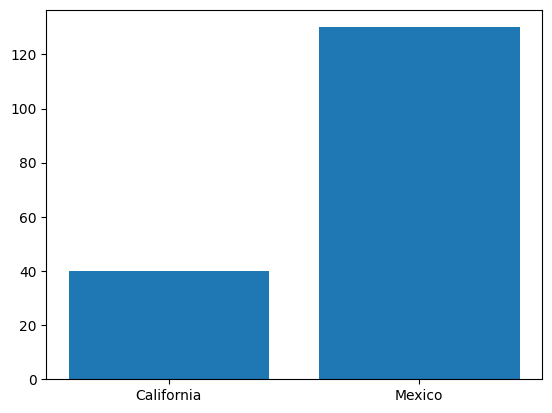

Observation: Successfully draw the bar figure!
Agent plot_agent takes 2-step Action:
{
	name: Finish
	params: {'response': 'Done!'}
}
Observation: Done!
=========plot_agent finish execution. TaskPackage[ID:7eeec8b6-333b-4a07-a0aa-ce667c08f859] status:
[
	completion: completed
	answer: Done!
]
Observation: Done!
Agent plot_agent takes 2-step Action:
{
	name: Finish
	params: {'response': 'Done!'}
}
Observation: Done!
=========plot_agent finish execution. TaskPackage[ID:7eeec8b6-333b-4a07-a0aa-ce667c08f859] status:
[
	completion: completed
	answer: Done!
]
Observation: Done!
Agent manager_agent takes 4-step Action:
{
	name: Finish
	params: {'response': 'The bar figure for the population of California and Mexico has been successfully plotted with values of 40 million and 130 million respectively.'}
}
Observation: The bar figure for the population of California and Mexico has been successfully plotted with values of 40 million and 130 million respectively.
=========manager_agent finish exec

In [23]:
# run test
test_task = "plot the bar figure of California and Mexico population."
test_task_pack = TaskPackage(instruction=test_task, task_creator="User")
response = manager_agent(test_task_pack)
print(response)